# Customer Segmentation using Autoencoder + KMeans

# Customer Segmentation using Autoencoder + KMeans

In [ ]:
# -------------------------------
# 1. Install required libraries
# -------------------------------
!pip install -q kagglehub tensorflow scikit-learn pandas matplotlib seaborn

In [ ]:
# -------------------------------
# 2. Download dataset from KaggleHub
# -------------------------------
import kagglehub
import os

# Download latest version of the dataset
dataset_path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", dataset_path)

# Construct the full path to Mall_Customers.csv within the downloaded directory
csv_file_path = os.path.join(dataset_path, 'Mall_Customers.csv')

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [ ]:
# -------------------------------
# 3. Import libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# -------------------------------
# 4. Load dataset
# -------------------------------
df = pd.read_csv(csv_file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [ ]:
# -------------------------------
# 5. Data preprocessing
# -------------------------------
# Encode Gender column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])   # Male/Female -> numeric

# Select features
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nProcessed feature shape:", X_scaled.shape)


Processed feature shape: (200, 4)


In [ ]:
# -------------------------------
# 6. Build Autoencoder
# -------------------------------
input_dim = X_scaled.shape[1]
encoding_dim = 2   # latent space for visualization

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(8, activation='relu')(input_layer)
x = Dense(4, activation='relu')(x)
latent = Dense(encoding_dim, activation='linear', name='latent_space')(x)

# Decoder
x = Dense(4, activation='relu')(latent)
x = Dense(8, activation='relu')(x)
output_layer = Dense(input_dim, activation='linear')(x)

# Models
autoencoder = Model(inputs=input_layer, outputs=output_layer)
encoder = Model(inputs=input_layer, outputs=latent)

# Compile
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("\nAutoencoder Summary:")
autoencoder.summary()


Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174 (696.00 B)

 Trainable params: 174 (696.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -------------------------------
# 7. Train Autoencoder
# -------------------------------
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.9437 - val_loss: 1.3721
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9284 - val_loss: 1.3812
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9159 - val_loss: 1.3912
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9043 - val_loss: 1.4043
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8952 - val_loss: 1.4156
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8876 - val_loss: 1.4261
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8815 - val_loss: 1.4364
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8746 - val_loss: 1.4450
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8676 - val_loss: 1.4546
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8589 - val_loss: 1.4632
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8489 - val_loss: 1.4714
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

In [ ]:
# -------------------------------
# 8. Extract latent features
# -------------------------------
encoded_data = encoder.predict(X_scaled)

print("\nEncoded data shape:", encoded_data.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Encoded data shape: (200, 2)


In [ ]:
# -------------------------------
# 9. Find best number of clusters
# -------------------------------
silhouette_scores = []
cluster_range = range(2, 8)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(encoded_data)
    score = silhouette_score(encoded_data, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

best_k = cluster_range[np.argmax(silhouette_scores)]
print("\nBest number of clusters:", best_k)

Clusters: 2, Silhouette Score: 0.5421
Clusters: 3, Silhouette Score: 0.5576
Clusters: 4, Silhouette Score: 0.5499
Clusters: 5, Silhouette Score: 0.5434
Clusters: 6, Silhouette Score: 0.5118
Clusters: 7, Silhouette Score: 0.5209

Best number of clusters: 3


In [ ]:
# -------------------------------
# 10. Apply KMeans with best_k
# -------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(encoded_data)

df['Cluster'] = clusters

final_silhouette = silhouette_score(encoded_data, clusters)
print("\nFinal Silhouette Score:", round(final_silhouette, 4))


Final Silhouette Score: 0.5576


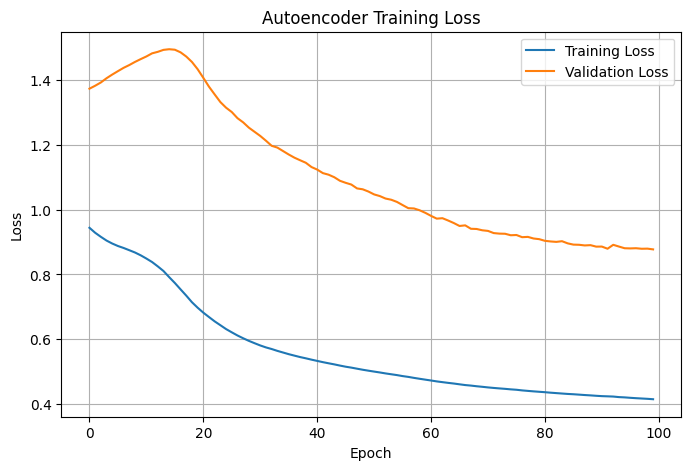

In [ ]:
# -------------------------------
# 11. Plot training loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

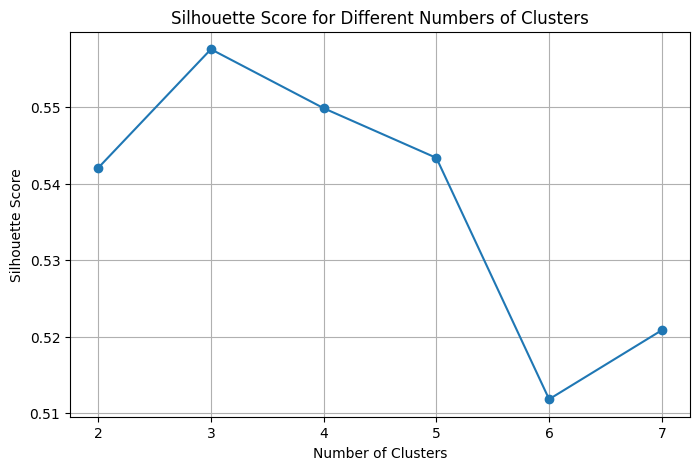

In [ ]:
# -------------------------------
# 12. Plot silhouette scores
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(cluster_range), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

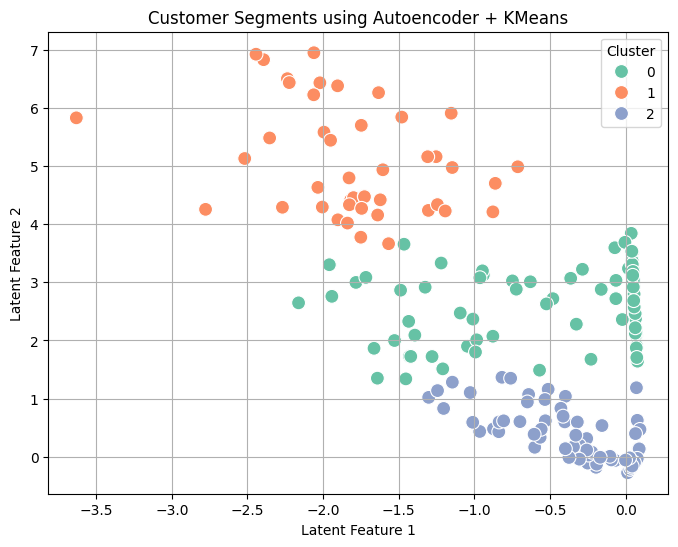

In [ ]:
# -------------------------------
# 13. Visualize clusters in latent space
# -------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=encoded_data[:, 0],
    y=encoded_data[:, 1],
    hue=clusters,
    palette='Set2',
    s=100
)
plt.title('Customer Segments using Autoencoder + KMeans')
plt.xlabel('Latent Feature 1')
plt.ylabel('Latent Feature 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

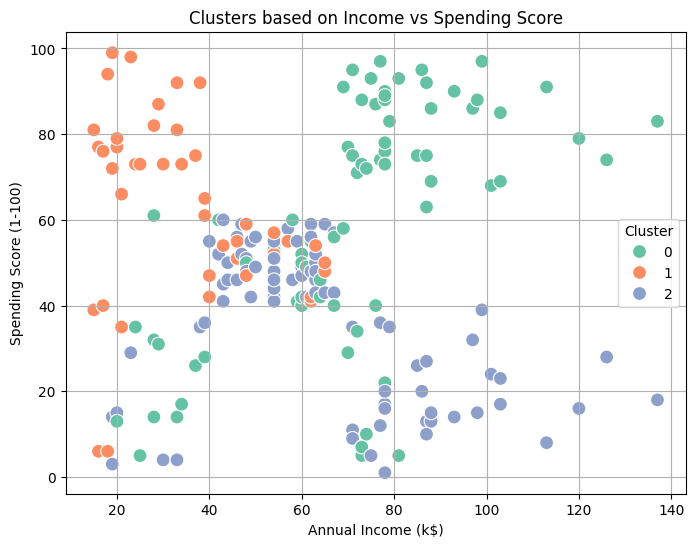

In [ ]:
# -------------------------------
# 14. Compare clusters using original features
# -------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=100
)
plt.title('Clusters based on Income vs Spending Score')
plt.grid(True)
plt.show()

In [ ]:
# -------------------------------
# 15. Cluster summary
# -------------------------------
print("\nCluster-wise Mean Values:")
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())


Cluster-wise Mean Values:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        33.133333           70.746667               59.720000
1        24.795455           35.113636               61.977273
2        51.777778           64.950617               34.987654

Number of customers in each cluster:
Cluster
0    75
1    44
2    81
Name: count, dtype: int64


In [ ]:
# -------------------------------
# 16. Save clustered output
# -------------------------------
output_file = '/content/customer_segmented_output.csv'
df.to_csv(output_file, index=False)
print(f"\nClustered dataset saved to: {output_file}")

# Optional: download file
from google.colab import files
files.download(output_file)


Clustered dataset saved to: /content/customer_segmented_output.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Customer Segmentation Report

### 1. Introduction
This report details a customer segmentation analysis performed on Mall Customer data. The objective is to identify distinct customer groups based on their demographic and spending habits, which can inform targeted marketing strategies and business decisions.

### 2. Methodology

*   **Data Preprocessing**: The dataset was loaded, and the 'Gender' feature was encoded numerically. Key features ('Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)') were selected and standardized.
*   **Autoencoder for Feature Reduction**: An autoencoder neural network was built and trained to reduce the dimensionality of the standardized features to a 2-dimensional latent space. This allows for effective visualization and improved clustering performance.
*   **KMeans Clustering**: The KMeans algorithm was applied to the 2-dimensional latent features. The optimal number of clusters was determined using the Silhouette Score method, which indicated 3 clusters as the best fit.

### 3. Key Findings (Cluster-wise Mean Values):

| Cluster | Age (Mean) | Annual Income (k$) (Mean) | Spending Score (1-100) (Mean) |
|---------|------------|---------------------------|-------------------------------|
| 0       | 33.13      | 70.75                     | 59.72                         |
| 1       | 24.80      | 35.11                     | 61.98                         |
| 2       | 51.78      | 64.95                     | 34.99                         |

**Interpretation of Clusters:**

*   **Cluster 0 (Target Customers)**: This segment consists of middle-aged customers with higher average annual incomes and moderate to high spending scores. They are likely a valuable segment for premium products and loyalty programs.
*   **Cluster 1 (Young Spenders)**: This cluster represents younger customers with lower annual incomes but very high spending scores. They might be impulse buyers or highly influenced by trends. Marketing efforts could focus on trendy, affordable items.
*   **Cluster 2 (Conservative Shoppers)**: This segment includes older customers with moderate incomes but significantly lower spending scores. They are likely more budget-conscious or only buy necessities. Strategies could involve value-for-money offers or essential goods.

### 4. Visualizations

*   **Autoencoder Training Loss**: The training history showed the loss decreasing over epochs, indicating that the autoencoder learned to reconstruct the input data effectively.
*   **Silhouette Scores**: The plot confirmed that 3 clusters yielded the highest silhouette score, validating the choice for `best_k`.
*   **Latent Space Clusters**: The scatter plot of the latent features clearly showed distinct groupings corresponding to the identified clusters.
*   **Income vs. Spending Score Clusters**: This visualization provided further insight into how the clusters are separated based on these two crucial features, aligning with the numerical summary.

### 5. Conclusion and Next Steps

This analysis successfully identified three distinct customer segments, providing actionable insights for the business. The clustered dataset has been saved to `/content/customer_segmented_output.csv`.

**Further steps could include:**

*   Developing tailored marketing campaigns for each customer segment.
*   Analyzing product preferences within each cluster.
*   Monitoring cluster behavior over time to identify shifts in customer preferences.